## imports

In [ ]:
import os
import time
import traceback
try: import uncertainties
except: os.system("pip install uncertainties")

In [ ]:
from uncertainties import ufloat
from uncertainties import unumpy as unp
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as opt
from scipy.optimize import curve_fit
import pandas as pd
import scipy.signal as sig

@np.vectorize
def pr(obj,label=None, split = False):
  if callable(obj):
    def new_func(*args,**kwargs):
      result=obj(*args,**kwargs)
      if label: print(label.format(*result)) if split else print(label.format(result))
      else:
        if split:
          for r in result: print(r)
        else: print(result)
      return result
    return new_func

  else:
    if label: print(label.format(*obj)) if split else print(label.format(obj))
    else:
      if split:
        for r in obj: print(r)
      else: print(obj)
    return obj


agree = lambda x,y: (np.abs(x.n-y.n) <= np.sqrt(np.square(x.s)+np.square(y.s)))
v_err = lambda v: 0.013*np.abs(v) + 0.008*(10**np.floor(np.log10(v)))
a_err = lambda a: 0.015*np.abs(a) + 0.008*(10**np.floor(np.log10(a)))
r_err = lambda r: 0.01*np.abs(r) + 0.005*(10**np.floor(np.log10(r))) if r!=0 else 0.005
c_err = lambda f: 0.04*np.abs(f) + 0.05*(10**np.floor(np.log10(f))) if f!=0 else 0.5

@np.vectorize
def u_convert(arr,err_fn):
  if callable(err_fn):
    return ufloat(arr,err_fn(arr))
  else: return ufloat(arr,err_fn)

def compare(a,b, prefix="", labels = ("Predicted: {:.3e}","Measured: {:.3e}","agree: {}"), ):
  print(" | ".join((prefix,)+labels).format(a,b,agree(a,b)))

pi = np.pi
sqrt = np.sqrt
sin = np.sin
cos = np.cos
tan = np.tan
ln = np.log
log = np.log10
square = np.square
exp = np.exp

u=ufloat
uc = u_convert
r_c = lambda x: u_convert(x,r_err)
nom = unp.nominal_values
std = unp.std_devs

## initial angle testing

In [ ]:
# Two Microphone System Angle Approx

In [ ]:

ssound = 343  # speed of sound in m/s
f = 4e4 # frequency of sound in Hz

d = u(0.107, 0.001) # distance between microphones in m
r = u(2.45, 0.02)  # distance from source to center of microphones in m

#lag = d*cos(theta)/s

# positions of microphones in m
shifts = np.array([(u(0,1e4), u(0,1e-6)), (u(1e-2,1e-4), u(1.5e-6,1.5e-6)), 
                    (u(2e-2,1e-4), u(3.5e-6, 1.5e-6)), (u(5e-2,1e-4), u(7.3e-6, 1.5e-6)),
                    (u(10e-2,1e-4), u(12.5e-6, 1.5e-6)), (u(15e-2,1e-4), u(20.5e-6, 1.5e-6)), 
                    (u(20e-2,1e-4), u(25.5e-6, 2e-6)), (u(25e-2,1e-4), u(28.5e-6, 2e-6)), (u(30e-2,1e-4), u(38e-6, 2e-6)), (u(40e-2,1e-4), u(48e-6, 2e-6))])  # time shifts of microphones in s
mictest2 = pd.DataFrame(shifts, columns=["position", "time_shift"])

lag = mictest2["time_shift"]

theta = unp.arcsin(lag*ssound/d)*180/pi
theta_th = unp.arctan(mictest2["position"]/r)*180/pi

for th2, th1,pos in zip(theta,theta_th,mictest2["position"]):
    compare(th1, th2, f"position: {pos:.2f} m", ("Predicted angle: {:.2f}°","Measured angle: {:.2f}°","agree: {}"))



position: 0.00+/-10000.00 m | Predicted angle: 0.00+/-233860.32° | Measured angle: 0.00+/-0.18° | agree: True
position: 0.01+/-0.00 m | Predicted angle: 0.23+/-0.00° | Measured angle: 0.28+/-0.28° | agree: True
position: 0.02+/-0.00 m | Predicted angle: 0.47+/-0.00° | Measured angle: 0.64+/-0.28° | agree: True
position: 0.05+/-0.00 m | Predicted angle: 1.17+/-0.01° | Measured angle: 1.34+/-0.28° | agree: True
position: 0.10+/-0.00 m | Predicted angle: 2.34+/-0.02° | Measured angle: 2.30+/-0.28° | agree: True
position: 0.15+/-0.00 m | Predicted angle: 3.50+/-0.03° | Measured angle: 3.77+/-0.28° | agree: True
position: 0.20+/-0.00 m | Predicted angle: 4.67+/-0.04° | Measured angle: 4.69+/-0.37° | agree: True
position: 0.25+/-0.00 m | Predicted angle: 5.83+/-0.05° | Measured angle: 5.24+/-0.37° | agree: False
position: 0.30+/-0.00 m | Predicted angle: 6.98+/-0.06° | Measured angle: 7.00+/-0.38° | agree: True
position: 0.40+/-0.00 m | Predicted angle: 9.27+/-0.07° | Measured angle: 8.85+/-

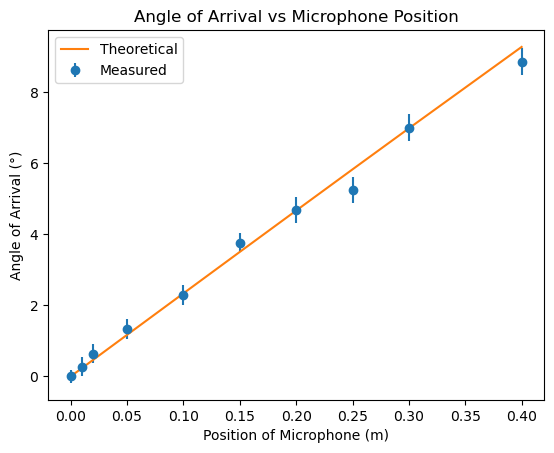

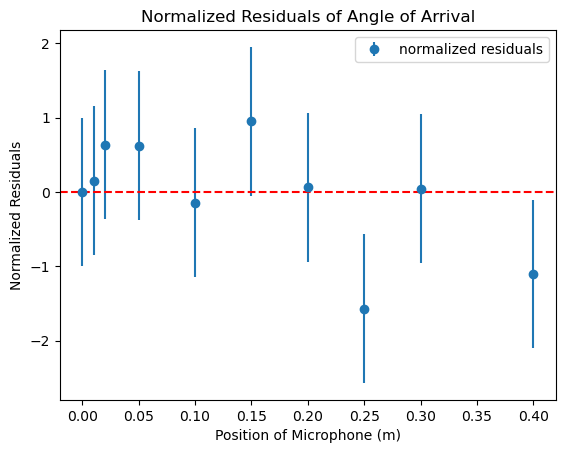

Chi-squared: 5.43
Chi-squared: 5.43


In [ ]:
plt.errorbar(unp.nominal_values(mictest2["position"]), unp.nominal_values(theta), yerr=unp.std_devs(theta), fmt='o', label="Measured")
plt.plot(unp.nominal_values(mictest2["position"]), unp.nominal_values(theta_th), label="Theoretical")
plt.xlabel("Position of Microphone (m)")
plt.ylabel("Angle of Arrival (°)")
plt.title("Angle of Arrival vs Microphone Position")
plt.legend()
plt.show()

plt.errorbar(unp.nominal_values(mictest2["position"]),(unp.nominal_values(theta)-unp.nominal_values(theta_th))/unp.std_devs(theta),yerr = np.ones_like(theta), fmt='o', label="normalized residuals")
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Position of Microphone (m)")
plt.ylabel("Normalized Residuals")
plt.title("Normalized Residuals of Angle of Arrival")
plt.legend()
plt.show()
chisq_2mic = pr(np.sum(np.square((unp.nominal_values(theta)-unp.nominal_values(theta_th))/unp.std_devs(theta))),"Chi-squared: {:.2f}")


## Wavegen Setup

In [ ]:
"""
Important objects:
    ADSHardware (class): a collection of methods for interfacing with the ADS
        variables:
            handle: address to connect to the ADS
        functions:
            startup: connects to ADS
            open_scope: opens connection to oscilloscope
            trigger_scope: sets trigger level for scope (buggy)
            read_scope: collects data from oscilloscope
            close_scope: closes connection to oscilloscope
            use_wavegen: outputs function at wavegen
            close_wavegen: closes connection to wavegen
            disconnect: closes connection to ADS
    oscilloscope_run (function): opens connection to and collects data from scope
    wavegen_functions (dict): easy names to access major types of functions wavegen can output

"""
from WF_SDK import device
from WF_SDK import scope
from WF_SDK import wavegen

In [ ]:
class ADSHardware():
    """Class of functions for interfacing with the ADS.
    """

    def __init__(self):
        self.handle = None

    def startup(self):
        """Connects to the ADS. Defines 'handle', the address to the ADS.
        Must be run at the beginning of every program using the ADS.
        """
        self.handle = device.open()

    def open_scope(self, buffer_size=1000, sample_freq=1e6):
        """Opens connection to the scope.

        Args:
            buffer_size (int, optional): How many data points are temporarily stored
            before being returned. The buffer is a temporary slot for storing a small amount of
            data before it is transferred to its final destination. Defaults to 1000.
            sample_freq (int, optional): How frequently the oscilloscope will sample
            from the input. Defaults to 1e6. You can decrease this if you have too
            many data points/the function is taking awhile to run for the time scale you need.
            (16e3 can be a reasonable selection.)
        """
        scope.open(self.handle, buffer_size=buffer_size, sampling_frequency=sample_freq)

    def trigger_scope(self, channel=1, level=0.1):
        """Sets trigger level for the scope. Kind of a buggy function; not used.

        Args:
            channel (int, optional): Selects which channel of scope to read out. 
            Defaults to 1.
            level (float, optional): Sets trigger level for scope. Defaults to 0.1.
        """
        scope.trigger(self.handle, enable=True, source=scope.trigger_source.analog, channel=channel,
                      edge_rising=True, level=level)

    def read_scope(self, channel=1):
        """Collects data from the scope.

        Args:
            channel (int, optional): Which channel to read from. Defaults to 1.

        Returns:
            buffer (array): An array of output data points. The buffer is a temporary slot 
            for storing a small amount of data before it is transferred to its final destination.
        """
        buffer = scope.record(self.handle, channel=channel)
        return buffer

    def close_scope(self):
        """Closes connection to the scope.
        """
        scope.close(self.handle)

    def use_wavegen(self, channel=1, function=wavegen.function.sine, offset_v=0, freq_hz=1e3, amp_v=1):
        """Runs the wavegen producing function with given parameters.

        Args:
            channel (int, optional): Which channel output is at. Defaults to 1.
            function (function object, optional): What type of function to output. 
            Defaults to wavegen.function.sine.
            offset (int, optional): Voltage offset (V). Defaults to 0.
            freq (int, optional): Frequency (Hz). Defaults to 1e3.
            amp (int, optional): Amplitude (V). Defaults to 1.
        """
        wavegen.generate(self.handle, channel=channel, function=function, offset=offset_v,
                         frequency=freq_hz, amplitude=amp_v)

    def close_wavegen(self):
        """Closes wavegen.
        """
        wavegen.close(self.handle)

    def disconnect(self):
        """Closes ADS connection. Must be run at the end of every program.
        """
        device.close(self.handle)

def oscilloscope_run(ads_object: ADSHardware, duration: int, channel: int, sampling_freq=500):
    """Collects data from the oscilloscope.

    Args:
        ads_object (ADSHardware object): the ADS being used
        duration (int): time length of trace to collect in seconds
        channel (int): which channel to collect data from
        sampling_freq (int, optional): How frequently the oscilloscope will sample
        from the input. Defaults to 500. You can decrease this if you have too
        many data points/the function is taking awhile to run for the time scale you need.
        (16e3 can be a reasonable selection.)

    Returns:
        data (dict): has two keys, "x" and "y" which have time (ms) and voltage (V) data
    """
    buffer_size = int(duration * sampling_freq)
    data = {}
    ads_object.open_scope(sample_freq=sampling_freq, buffer_size=buffer_size)

    MS_CONVERSION = 1e3

    buffer = ads_object.read_scope()
    data["y"] = buffer

    # MODIFY THE LINE BELOW THIS ONE IN L10.2(d)
    data["x"] = np.arange(buffer_size)*MS_CONVERSION/sampling_freq

    ads_object.close_scope()
    return data

def oscilloscope_run(ads_object: ADSHardware, duration: int, channel: int, sampling_freq=500):
    """Collects data from the oscilloscope.

    Args:
        ads_object (ADSHardware object): the ADS being used
        duration (int): time length of trace to collect in seconds
        channel (int): which channel to collect data from
        sampling_freq (int, optional): How frequently the oscilloscope will sample
        from the input. Defaults to 500. You can decrease this if you have too
        many data points/the function is taking awhile to run for the time scale you need.
        (16e3 can be a reasonable selection.)

    Returns:
        data (dict): has two keys, "x" and "y" which have time (ms) and voltage (V) data
    """
    
    buffer_size = int(duration * sampling_freq)
    data = {}
    ads_object.open_scope(sample_freq=sampling_freq, buffer_size=buffer_size)

    MS_CONVERSION = 1e3

    buffer = ads_object.read_scope()

    data["y"] = buffer
    data["x"] = np.arange(buffer_size)*MS_CONVERSION/sampling_freq

    ads_object.close_scope()

    return data

wavegen_functions = {"sine":wavegen.function.sine, "square":wavegen.function.square,
                     "triangle":wavegen.function.triangle, "dc":wavegen.function.dc}

In [ ]:
# Startup ADS

ads1 = None
ads1 = ADSHardware()
try: ads1.disconnect()
except: pass
ads1.startup()

ads2 = None
ads2 = ADSHardware()
try: ads2.disconnect()
except: pass
ads2.startup()
ads1.handle.handle = 1
ads2.handle.handle = 2
print(ads1.handle.handle)
print(ads2.handle.handle)

adsT = None
adsR = None

# Ads with highest recieved signal is adsT
ads1.use_wavegen(channel=1, function=wavegen.function.sine, offset_v=0, freq_hz=4e4, amp_v=1)
datatest1 = oscilloscope_run(ads1, duration=0.1, channel=1, sampling_freq=16e3)
ads1.close_wavegen()
ads2.use_wavegen(channel=1, function=wavegen.function.sine, offset_v=0, freq_hz=4e4, amp_v=1)
datatest2 = oscilloscope_run(ads2, duration=0.1, channel=1, sampling_freq=16e3)
ads2.close_wavegen()

if np.max(np.abs(datatest1["y"])) > np.max(np.abs(datatest2["y"])):
    adsT = ads1
    adsR = ads2
    print("ads1 is transmitter, ads2 is receiver")
else:
    adsT = ads2
    adsR = ads1
    print("ads2 is transmitter, ads1 is receiver")



Connected to Analog Discovery 2
Device handle: 1
Connected to Analog Discovery 2
Device handle: 2
2
2
ads1 is transmitter, ads2 is receiver


## 1D Non Degenerate Measures (3 mics) Full

In [ ]:
# measure function, split between ADST and ADSR

def measure(duration=0.1, channels={"R":[1,2],"T":[1]}, sampling_freq=16e3):

    buffer_size = int(duration * sampling_freq)
    data = {}

    adsT.open_scope(sample_freq=sampling_freq, buffer_size=buffer_size)
    adsR.open_scope(sample_freq=sampling_freq, buffer_size=buffer_size)

    MS_CONVERSION = 1e3
    buffer = []
    for key, channel in channels.items():
        if key == "T":
            for ch in channel:
                buffer.append(adsT.read_scope(ch))
        elif key == "R":
            for ch in channel:
                buffer.append(adsR.read_scope(ch))

    data["y"] = buffer
    data["x"] = np.arange(buffer_size)*MS_CONVERSION/sampling_freq

    adsT.close_scope()
    adsR.close_scope()

    return data

In [ ]:
ads1 = None
ads1 = ADSHardware()
try: ads1.disconnect()
except: pass
ads1.startup()

Connected to Analog Discovery 2
Device handle: 1


In [ ]:
ads2 = None
ads2 = ADSHardware()
try: ads2.disconnect()
except: pass
ads2.startup()

Connected to Analog Discovery 2
Device handle: 2


In [ ]:
ads1.handle.handle = 1


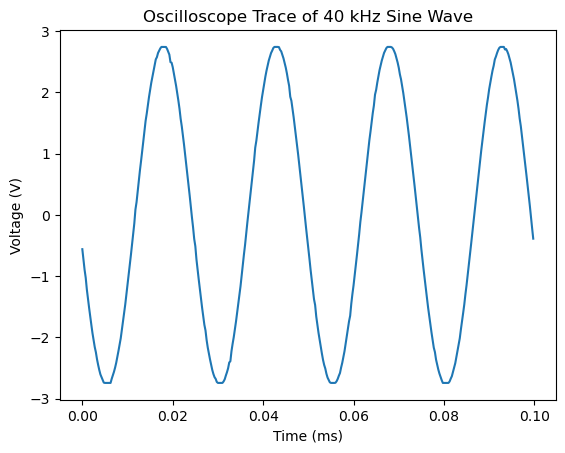

In [ ]:
ads1.use_wavegen(channel=1, function=wavegen_functions["sine"], offset_v=0, freq_hz=40e3, amp_v=2.75)
data = oscilloscope_run(ads1, duration=1e-4, channel=1, sampling_freq=4e6)
ads1.close_wavegen()

plt.plot(data["x"], data["y"])
plt.xlabel("Time (ms)")
plt.ylabel("Voltage (V)")
plt.title("Oscilloscope Trace of 40 kHz Sine Wave")
plt.show()

In [ ]:
ads3 = ads1

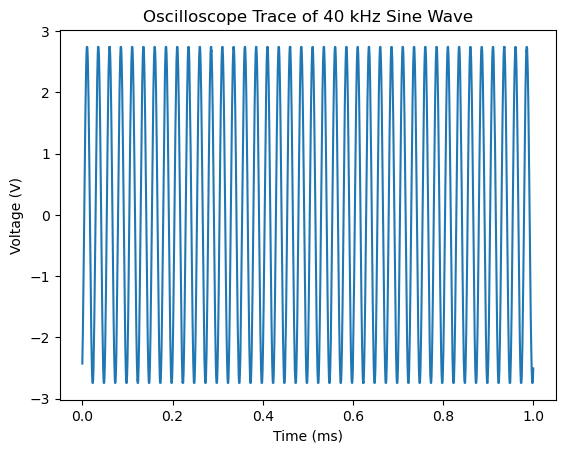

ValueError: x and y must have same first dimension, but have shapes (4000,) and (1,)

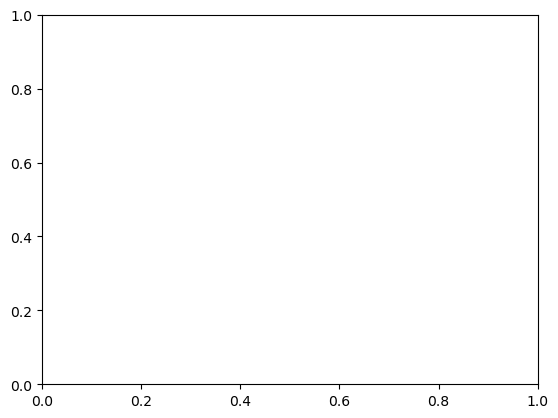

In [ ]:
# 1D collect data
# Want to run wavegen at 40 kHz, 5 V amplitude, 0 V offset, for 1 second, and collect data from channel 1 of the scope at a sampling frequency of 4000 kHz. Then plot the data.

ads1.use_wavegen(channel=1, function=wavegen_functions["sine"], offset_v=0, freq_hz=40e3, amp_v=2.75)
time.sleep(.1)
#data = measure(duration=1e-4, sampling_freq=4e6)
data = oscilloscope_run(ads1, duration=0.001, channel=1, sampling_freq=4e6)
ads1.close_wavegen()

plt.plot(data["x"], data["y"])
plt.xlabel("Time (ms)")
plt.ylabel("Voltage (V)")
plt.title("Oscilloscope Trace of 40 kHz Sine Wave")
plt.show()

for channel in data["y"]:
    plt.plot(data["x"], channel, label="Channel {}".format(data["y"].index(channel)+1))
plt.xlabel("Time (ms)")
plt.ylabel("Voltage (V)")
plt.title("Oscilloscope Trace of 40 kHz Sine Wave")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [ ]:
#Array geometry
d12_1d = _ # distance between mic 1 at origin and mic 2 on y
d1b_1d = _ # distance between mic 1 at origin and mic 3 on y at different distance from 2

# 1D position finder (2 mics, 1 origin, 1:x) for mics along an arc of constant r, with angle theta from the x axis
lagx_1d = lambda r1, theta : (np.sqrt(r1**2 - 2*r_fixed*d12_1d*np.cos(theta_1d) + d12_1d**2) - r_fixed)/ssound

# extra mic for non degenerate (place another mic along x such that d12 and d1x are coprime)
lagxb_1d = lambda r1, theta : (np.sqrt(r1**2 - 2*r_fixed*d1b_1d*np.cos(theta_1d) + d1b_1d**2) - r_fixed)/ssound

def equations1d(vars, lagx_1d_meas, lagxb_1d_meas):
    r1, theta = vars
    eq1 = lagx_1d(r1, theta) - lagx_1d_meas
    eq2 = lagxb_1d(r1, theta) - lagxb_1d_meas
    return [eq1, eq2]

r_fixed = 2.45 # fixed distance from souce to origin microphone (mic 1).
theta_1d_guess = 30*np.pi/180 # initial guess for theta
theta_1d = opt.fsolve(equations1d, (r_fixed, theta_1d_guess))

print(f"Estimated position: r={theta_1d[0]:.2f} m, theta={theta_1d[1]*180/pi:.2f}°")


TypeError: equations1d() missing 2 required positional arguments: 'lagx_1d_meas' and 'lagxb_1d_meas'

In [ ]:
# 2D position finder (L shape)
lag12 = lambda r1, theta : (np.sqrt(r1**2 - 2*r1*d12_2d*np.sin(theta) + d12_2d**2) - r1)/ssound
lag13 = lambda r1, theta : (np.sqrt(r1**2 - 2*r1*d13_2d*np.cos(theta) + d13_2d**2) - r1)/ssound

# 2D position finder non degenerate (place another mic along x such that d12 and d1x are coprime)
lag1b = lambda r1, theta : (np.sqrt(r1**2 - 2*r1*d1b_2d*np.sin(theta) + d1b_2d**2) - r1)/ssound

# Solve for theta and rs using lag12, lag13, and lag1b to remove degeneracy

def equations2d_nondeg(vars, lag12_meas, lag13_meas, lag1b_meas):
    r1, theta = vars
    eq1 = lag12(r1, theta) - lag12_meas
    eq2 = lag13(r1, theta) - lag13_meas
    eqd = lag1b(r1, theta) - lag1b_meas
    return [eq1, eq2, eqd]

[r1_guess, theta_guess] = [2.5, 45*np.pi/180]  # initial guess for r1 and theta, meters and radians
results_2d_nondeg = opt.fsolve(equations2d_nondeg, (r1_guess, theta_guess), args=(lag12_meas, lag1b_meas))



In [ ]:
# 3D position finder (3d axis shape, 1 origin, 4:x, 3:y, 2:z)
lag12 = lambda r1, theta : (np.sqrt(r1**2 - 2*r1*d12*np.cos(theta)) - r1)/ssound
lag13 = lambda r1, phi, theta : (np.sqrt(r1**2 - 2*r1*d13*np.sin(phi)*np.sin(theta)) - r1)/ssound
lag14 = lambda r1, phi, theta : (np.sqrt(r1**2 - 2*r1*d14*np.cos(phi)*np.sin(theta)) - r1)/ssound

# 3D position finder non degenerate (place another mic along z such that d12 and d1x are coprime)
Lag1b = lambda r1, theta : (np.sqrt(r1**2 - 2*r1*d1b*np.cos(theta) + d**2) - r1)/ssound
# Solve for theta and rs using lag12, lag13, and lag1b

